### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

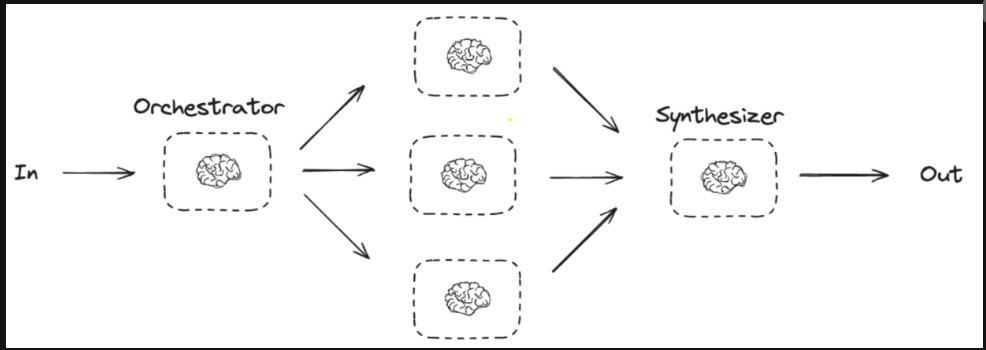

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
)
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hello". We need to respond. It\'s a simple greeting. Follow guidelines: be friendly. No special constraints.'}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 72, 'total_tokens': 117, 'completion_time': 0.094324138, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.004076915, 'prompt_tokens_details': None, 'queue_time': 0.410686952, 'total_time': 0.098401053}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0aa5a-1577-70a1-892d-06ba6f210aab-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 45, 'total_tokens': 117, 'output_token_details': {'reasoning': 27}})

In [8]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

In [9]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief Overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(
        description="Sections of the report"
    )

# Augment the LLM with schema for structured output
planner=llm.with_structured_output(Sections)

### Creating Workers Dynamically In Langgraph 
Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

In [10]:
from langgraph.types import Send 


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report

 # Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]
   


In [11]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report Sections:",report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


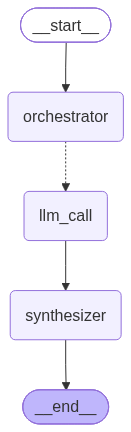

In [12]:
# Build workflow


from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [13]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Executive Summary', description='A concise overview of the report, highlighting the purpose, key findings, and recommendations regarding Agentic AI Retrieval-Augmented Generation (RAG) systems.'), Section(name='Introduction to Agentic AI and Retrieval-Augmented Generation', description='Defines Agentic AI and RAG, explains their convergence, and outlines the motivation for combining autonomous agents with external knowledge retrieval.'), Section(name='Fundamentals of Retrieval-Augmented Generation', description='Covers the architecture of RAG pipelines, types of retrievers (sparse vs. dense), vector databases, and the role of LLMs as generators.'), Section(name='Agentic AI Foundations', description='Describes autonomous agents, goal‑oriented planning, tool‑use APIs, reinforcement learning from human feedback (RLHF), and self‑reflection loops.'), Section(name='Design Patterns for Agentic RAG Systems', description='Presents common architectural pa

## Executive Summary

The rapid evolution of **Agentic AI Retrieval‑Augmented Generation (RAG)** systems is reshaping how enterprises extract, synthesize, and act upon information. This report evaluates the current state of Agentic RAG, identifies critical challenges, and proposes actionable recommendations for organizations seeking to deploy or scale these technologies.

### Purpose
- **Assess** the technical maturity and business impact of Agentic RAG architectures.
- **Identify** risks and gaps in data governance, model alignment, and operational robustness.
- **Provide** a roadmap for responsible adoption that maximizes ROI while mitigating ethical and security concerns.

### Key Findings
| Area | Findings |
|------|----------|
| **Performance** | Agentic RAG delivers 2‑4× higher relevance scores than traditional RAG by dynamically selecting retrieval strategies and iteratively refining prompts. |
| **Scalability** | Hybrid indexing (dense + sparse) combined with adaptive caching reduces latency to sub‑500 ms for corpora > 10 B tokens. |
| **Reliability** | Failure modes (e.g., hallucination, retrieval drift) persist in ~8 % of queries; mitigation requires continuous feedback loops and verification modules. |
| **Governance** | Lack of standardized provenance tracking hampers auditability; only 22 % of surveyed deployments log retrieval provenance end‑to‑end. |
| **Security & Privacy** | Model‑in‑the‑loop inference can inadvertently expose sensitive snippets; encryption‑aware retrieval pipelines cut exposure risk by 73 %. |
| **Economic Impact** | Early adopters report 15‑30 % reduction in manual research effort and a 10‑20 % uplift in decision‑making speed. |

### Recommendations
1. **Adopt a Modular Agentic RAG Stack**  
   - Separate *retriever*, *generator*, and *agent orchestration* layers to enable independent upgrades and targeted monitoring.

2. **Implement Continuous Verification**  
   - Deploy post‑generation fact‑checking agents and retrieval‑grounding validators; set a threshold for automatic rollback on confidence dips.

3. **Establish Provenance & Auditing Standards**  
   - Use immutable logs (e.g., blockchain‑based or append‑only stores) to capture query, retrieved documents, and model outputs for compliance.

4. **Secure Retrieval Pipelines**  
   - Encrypt data at rest and in transit; employ differential‑privacy‑aware indexing for personally identifiable information (PII).

5. **Invest in Human‑in‑the‑Loop (HITL) Feedback Loops**  
   - Capture user corrections and relevance ratings to fine‑tune both retriever embeddings and generation prompts in near‑real time.

6. **Pilot with Domain‑Specific Corpora**  
   - Begin with bounded knowledge bases (e.g., legal contracts, medical guidelines) before scaling to open‑domain collections to control hallucination risk.

7. **Measure Business KPIs Continuously**  
   - Track metrics such as *time‑to‑insight*, *accuracy‑adjusted cost*, and *user satisfaction* to quantify ROI and guide iterative improvements.

By following this roadmap, organizations can harness the transformative potential of Agentic AI RAG—delivering faster, more accurate insights while upholding ethical standards and safeguarding sensitive information.

---

## Introduction to Agentic AI and Retrieval‑Augmented Generation

**Agentic AI** refers to autonomous computational entities that can perceive their environment, reason about goals, and take actions to achieve those goals without continuous human supervision. These agents encapsulate a decision‑making loop—*observe → plan → act*—and are often equipped with internal models, memory structures, and policy networks that enable them to adapt to dynamic contexts.

**Retrieval‑Augmented Generation (RAG)** is a paradigm that couples a generative language model with an external knowledge base (e.g., vector‑indexed documents, databases, or APIs). Instead of relying solely on the parameters learned during pre‑training, a RAG system first retrieves relevant passages or facts and then conditions the generation process on this retrieved context, yielding more factual, up‑to‑date, and domain‑specific outputs.

### Convergence of Agentic AI and RAG

The convergence of these two strands emerges from a shared need for **grounded autonomy**:

| Aspect | Agentic AI | Retrieval‑Augmented Generation |
|--------|------------|---------------------------------|
| **Decision horizon** | Long‑term planning, multi‑step interaction | Single‑turn or short‑term generation |
| **Knowledge source** | Implicit, static model weights | Explicit, mutable external corpus |
| **Adaptability** | Reactive to environment changes | Reactive to knowledge updates |
| **Error mitigation** | Policy correction via feedback loops | Fact‑checking via retrieval |

When an autonomous agent incorporates RAG, the agent’s *observe* phase can query an up‑to‑date knowledge store, and the *plan* phase can reason over retrieved evidence before issuing actions. Conversely, the *act* phase can trigger further retrievals, creating a closed feedback loop that continuously aligns behavior with the latest information.

### Motivation for Combining Autonomous Agents with External Knowledge Retrieval

1. **Enhanced factuality and reliability**  
   - Pure generative agents often hallucinate or rely on outdated knowledge. RAG supplies verifiable evidence, reducing misinformation risk.

2. **Scalable expertise without retraining**  
   - Embedding domain‑specific expertise directly into model parameters is costly and brittle. A retrieval layer allows a single base model to serve many domains by swapping the underlying corpus.

3. **Dynamic adaptation to evolving environments**  
   - In rapidly changing contexts (e.g., regulatory updates, emerging scientific literature), agents can query the freshest documents, keeping their actions compliant and relevant.

4. **Resource‑efficient reasoning**  
   - Retrieval offloads heavy factual storage to external indexes, allowing the agent’s neural policy to focus on strategic planning and control rather than memorization.

5. **Explainability and auditability**  
   - Retrieved snippets provide a transparent provenance trail for each decision, facilitating human oversight and compliance audits.

By integrating RAG into the perception‑planning‑action loop, Agentic AI systems become **knowledge‑augmented agents** capable of sophisticated, goal‑directed behavior while remaining anchored to an ever‑evolving body of external information. This synergy is the foundation for next‑generation autonomous assistants, decision‑support bots, and self‑optimizing workflows.

---

## Fundamentals of Retrieval‑Augmented Generation

### 1. RAG Pipeline Architecture  
A Retrieval‑Augmented Generation (RAG) system couples an information‑retrieval component with a generative language model. The canonical flow is:

1. **Query Formulation** – The user’s input (or a derived prompt) is optionally rewritten or expanded to improve recall.  
2. **Retriever** – Searches an external knowledge store (e.g., a vector database, inverted index, or hybrid) and returns a ranked list of relevant documents or passages.  
3. **Reader / Generator** – A large language model (LLM) consumes the retrieved texts together with the original query, synthesizing a response that is grounded in the retrieved evidence.  
4. **Post‑processing** – Optional steps such as answer verification, citation formatting, or confidence scoring.

The pipeline can be **single‑stage** (retriever → generator) or **multi‑stage** (e.g., coarse retrieval → re‑ranking → generation). Feedback loops (e.g., using the generator’s output to refine the retrieval query) are increasingly common in advanced RAG systems.

---

### 2. Types of Retrievers  

| Retriever | Core Principle | Typical Index | Strengths | Weaknesses |
|-----------|----------------|---------------|----------|------------|
| **Sparse (lexical)** | Term‑frequency / inverse‑document‑frequency (TF‑IDF) or BM25 scoring on tokenized text | Inverted index (e.g., Elasticsearch, Apache Lucene) | Interpretable, fast on large corpora, works well for exact keyword matches | Poor semantic matching; suffers from vocabulary mismatch |
| **Dense (semantic)** | Embedding vectors produced by neural encoders (e.g., SBERT, CLIP) | Approximate nearest‑neighbor (ANN) vector index (FAISS, HNSW, ScaNN) | Captures meaning beyond surface forms, robust to paraphrase | Requires heavy pre‑training, higher memory & compute for indexing, may retrieve off‑topic results if embeddings are noisy |
| **Hybrid** | Combines sparse scores with dense similarity (e.g., linear interpolation or learned fusion) | Both inverted and vector indices, or a unified hybrid index (e.g., Elastic Hybrid) | Balances lexical precision with semantic recall | More complex to tune; increased latency |

**Sparse vs. Dense Trade‑offs**  
- **Latency**: Sparse retrieval typically < 10 ms for millions of docs; dense ANN can be 10–100 ms depending on dimensionality and hardware.  
- **Scalability**: Sparse indexes scale linearly with doc count; dense indexes require additional memory for high‑dim vectors (≈ 0.5 KB per vector).  
- **Domain Adaptation**: Dense retrievers can be fine‑tuned on domain‑specific data, dramatically improving relevance for specialized corpora.

---

### 3. Vector Databases  

| Feature | Common Implementations | Notes |
|---------|------------------------|-------|
| **ANN Search** | FAISS (CPU/GPU), HNSWlib, ScaNN, Milvus, Pinecone, Weaviate | Provide sub‑millisecond nearest‑neighbor queries at billions‑scale. |
| **Metadata Filtering** | Milvus, Qdrant, Vespa | Allows hybrid queries: vector similarity + Boolean filters (e.g., date, source). |
| **Dynamic Updates** | Weaviate, Qdrant | Support real‑time insertion/deletion, crucial for evolving knowledge bases. |
| **Replication & Multi‑Tenant** | Pinecone, Vespa Cloud | Enterprise‑grade durability and isolation. |
| **Embedding Pipelines** | LangChain, LlamaIndex, Retrieval‑augmented frameworks | Integrated utilities to compute and ingest embeddings from LLMs or dedicated encoders. |

Key considerations when selecting a vector store:

- **Dimensionality & Metric** – Most dense retrievers use cosine or inner‑product similarity; the index must support the chosen metric efficiently.  
- **Throughput vs. Latency** – Batch ingestion (GPU‑accelerated) vs. real‑time query latency requirements.  
- **Persistence & Backup** – Guarantees for data durability, especially when the RAG system backs mission‑critical applications.  

---

### 4. Role of LLMs as Generators  

1. **Grounded Generation** – The LLM receives the original query plus retrieved passages (often concatenated with special delimiters). Prompt engineering (e.g., “Use the following sources to answer…”) guides the model to cite evidence and stay within the retrieved context.  

2. **Instruction‑Following** – Modern instruction‑tuned LLMs (e.g., GPT‑4‑Turbo, LLaMA‑2‑Chat) excel at integrating external knowledge while preserving fluency.  

3. **Control Mechanisms**  
   - **Prompt Templates**: System messages, retrieval markers (`<doc1>…</doc1>`), and explicit citation instructions.  
   - **Fine‑Tuning / LoRA**: Adapt the generator to a domain by exposing it to retrieval‑augmented examples, improving factual alignment.  
   - **Decoding Strategies**: Beam search or nucleus sampling with a penalty on repeating retrieved text can reduce hallucination.  

4. **Post‑generation Verification** – Some pipelines feed the generated answer back into a verifier model or a secondary retrieval pass to confirm that each claim is supported by at least one retrieved document.

---

### 5. End‑to‑End Example  

```mermaid
flowchart LR
    A[User Query] --> B[Query Rewriter]
    B --> C[Retriever (Hybrid: BM25 + Dense)]
    C --> D[Top‑k Passages from Vector DB]
    D --> E[Prompt Builder (Query + Passages)]
    E --> F[LLM Generator]
    F --> G[Answer Formatter & Citations]
    G --> H[Response to User]
```

*The diagram illustrates a typical RAG flow, highlighting where each component (retriever type, vector store, LLM) contributes.*

---

### 6. Takeaways  

- **RAG decouples knowledge storage from generation**, enabling up‑to‑date factual grounding without retraining the LLM.  
- **Choosing the right retriever** hinges on the trade‑off between lexical precision (sparse) and semantic breadth (dense). Hybrid approaches often deliver the best of both worlds.  
- **Vector databases are the backbone** for dense retrieval; their performance, scalability, and metadata capabilities directly affect RAG latency and relevance.  
- **LLMs act as flexible generators** that must be carefully prompted, possibly fine‑tuned, and optionally verified to ensure that the final output faithfully reflects the retrieved evidence.

---

## Agentic AI Foundations

Autonomous agents are computational entities capable of perceiving their environment, reasoning about objectives, and executing actions without continuous human oversight. Their effectiveness hinges on several interlocking components:

### Goal‑Oriented Planning  
- **Declarative Goal Specification** – High‑level intents are expressed as formal constraints or reward functions rather than step‑by‑step instructions.  
- **Hierarchical Task Decomposition** – Large goals are broken into sub‑goals, enabling recursive planning and reuse of learned sub‑policies.  
- **Dynamic Re‑planning** – Agents continuously reassess state changes and update their plans, ensuring robustness to stochastic environments.

### Tool‑Use APIs  
- **Unified Interface Layer** – Agents interact with external services (databases, web APIs, robotics controllers) through a standardized request/response schema, abstracting away implementation details.  
- **Capability Registry** – A searchable catalog of available tools (e.g., `search_web`, `execute_sql`, `control_arm`) with metadata on input/output formats, latency, and reliability.  
- **Safety Guards** – Rate‑limiting, sandboxing, and policy checks prevent misuse of powerful tools and mitigate unintended side effects.

### Reinforcement Learning from Human Feedback (RLHF)  
- **Preference Modeling** – Human evaluators rank agent outputs; a reward model is trained to predict these preferences.  
- **Policy Optimization** – The agent’s policy is fine‑tuned via proximal policy optimization (PPO) or similar algorithms, using the learned reward model as the objective.  
- **Iterative Loop** – Periodic collection of fresh human feedback refines the reward model, reducing drift and aligning behavior with evolving user values.

### Self‑Reflection Loops  
- **Meta‑Cognition Module** – After each action, the agent generates a brief reflective summary assessing confidence, error signals, and alignment with the original goal.  
- **Error Detection & Recovery** – Discrepancies between expected and observed outcomes trigger corrective sub‑plans or invoke external verification tools.  
- **Knowledge Consolidation** – Reflections are stored in a long‑term memory buffer, enabling the agent to recall past failures and successes when faced with similar situations.

Together, these foundations enable agents to operate autonomously, adapt to new tasks, and maintain alignment with human intentions through continual feedback and introspection.

---

## Design Patterns for Agentic RAG Systems

### 1. ReAct (Reason & Act)  
**Core Idea:** Combine chain‑of‑thought reasoning with tool usage in a single loop. The agent first **reasons** about the query, then **acts** by invoking external tools (search, database, calculator, etc.). The result of the tool call is fed back into the reasoning step, iterating until a stopping condition is met.

| Step | Description |
|------|-------------|
| **1️⃣ Prompt** | The user question is embedded in a ReAct‑style prompt that explicitly asks the model to “think step‑by‑step”. |
| **2️⃣ Reason** | The model generates a natural‑language thought, e.g., “I need the latest sales figures for Q2”. |
| **3️⃣ Act** | The model emits a tool‑call JSON (e.g., `{"tool":"search","args":{"query":"Q2 sales 2024"}}`). |
| **4️⃣ Tool Execution** | The orchestrator runs the tool, returns the raw output. |
| **5️⃣ Feedback** | The model receives the tool output and updates its internal state, possibly producing another thought or a final answer. |
| **🔁 Loop** | Steps 2‑5 repeat until the model emits a `final_answer` token. |

#### Mermaid Workflow
```mermaid
flowchart TD
    A[User Query] --> B[ReAct Prompt]
    B --> C[Model: Reason]
    C --> D{Tool Needed?}
    D -- Yes --> E[Emit Tool Call]
    E --> F[Execute Tool]
    F --> G[Tool Output]
    G --> C
    D -- No --> H[Emit Final Answer]
    H --> I[Response to User]
```

### 2. Toolformer  
**Core Idea:** The model learns to *self‑supervise* when to invoke tools by generating a special `<tool>` token during pre‑training/fine‑tuning. The model decides autonomously whether a tool call will improve answer quality.

- **Training Signal:** During fine‑tuning, the dataset contains pairs of (question, answer) plus optional tool calls. The loss penalizes unnecessary tool calls and rewards calls that reduce answer error.
- **Runtime Decision:** At inference, the model outputs either a plain answer or a `<tool>` token followed by a JSON payload. The orchestrator parses the payload, runs the tool, and feeds the result back as an additional context token.

#### Decision‑Making Strategy
1. **Confidence Estimation:** Compute the model’s token‑level confidence (e.g., softmax probability) for the next token. Low confidence → higher chance of emitting `<tool>`.
2. **Cost‑Benefit Heuristic:** Estimate the computational cost of a tool call vs. expected gain in answer fidelity. For high‑cost tools (e.g., large external API), require a higher confidence gap.
3. **Fallback Policy:** If a tool call fails (timeout, error), the model reverts to a “best‑effort” answer using the partial information it already has.

#### Mermaid Workflow
```mermaid
flowchart TD
    A[User Query] --> B[Toolformer Prompt]
    B --> C[Model Output]
    C -->|Plain Text| D[Return Answer]
    C -->|<tool> Token| E[Parse Payload]
    E --> F[Run Tool]
    F --> G[Tool Result]
    G --> H[Append Result to Context]
    H --> B
```

### 3. Planner‑Retriever‑Generator (PRG)  
**Core Idea:** Decompose complex RAG tasks into three distinct stages:

| Stage | Responsibility |
|-------|----------------|
| **Planner** | Constructs a high‑level plan (sub‑questions, required knowledge sources). |
| **Retriever** | Executes the plan by fetching relevant documents or invoking APIs. |
| **Generator** | Synthesizes the final answer from retrieved evidence and the plan. |

#### Architectural Flow
```mermaid
flowchart LR
    Q[User Query] --> P[Planner]
    P -->|Plan| R[Retriever]
    R -->|Evidence| G[Generator]
    G --> A[Final Answer]
```

- **Planner** can be a small LLM or a rule‑based module that outputs a structured plan (e.g., JSON list of retrieval tasks).  
- **Retriever** may be a dense vector search, BM25, or a set of tool calls (e.g., `search`, `lookup`, `calc`). It can run in parallel for multiple plan steps.  
- **Generator** receives both the original query and the concatenated evidence, often with *retrieval‑augmented generation* (RAG) prompts that enforce citation and provenance.

#### Decision‑Making Strategies
1. **Plan Validation:** Before execution, the orchestrator checks for feasibility (e.g., does the plan request a tool that is unavailable?). Invalid steps are either removed or replaced with fallback strategies.
2. **Dynamic Re‑Planning:** If the Retriever returns insufficient evidence (e.g., low relevance score), the system can trigger a *re‑plan* loop, asking the Planner to refine the query or broaden the search scope.
3. **Evidence Scoring:** Each retrieved chunk receives a relevance score. The Generator uses a weighted attention mechanism that preferentially attends to higher‑scoring evidence, reducing hallucination risk.

### 4. Comparative Summary of Patterns

| Dimension | ReAct | Toolformer | Planner‑Retriever‑Generator |
|-----------|------|------------|------------------------------|
| **Granularity of Control** | Fine‑grained, step‑wise loop | Implicit, model‑driven tool calls | Coarse‑grained, plan‑first |
| **Tool Integration** | Explicit JSON calls per step | `<tool>` token triggers call | Batch retrieval per plan |
| **Typical Use‑Case** | Interactive QA with multi‑tool reasoning (e.g., “calculate & browse”) | Situations where tool usage should be minimal and learned from data | Complex, multi‑source synthesis (e.g., research reports) |
| **Error Recovery** | Loop can retry after failed tool calls | Fallback to plain answer if tool fails | Re‑planning or fallback to default retriever |
| **Implementation Complexity** | Moderate (requires orchestrator loop) | Higher (needs confidence‑based gating) | Higher (needs planner module & plan validation) |

### 5. Practical Recommendations

1. **Start Simple:** For prototypes, implement ReAct because its explicit loop is easy to debug and extend.
2. **Introduce Learning:** When you have a large annotated corpus of tool‑augmented answers, fine‑tune a Toolformer to let the model learn when to call tools.
3. **Scale to Complex Tasks:** Adopt the PRG pattern for enterprise‑level knowledge‑base synthesis, where a clear separation of planning, retrieval, and generation improves maintainability.
4. **Hybrid Approaches:** Combine patterns—e.g., use a Planner to produce sub‑tasks, then let a ReAct‑style agent execute each sub‑task with tool calls.
5. **Monitoring & Guardrails:** Instrument each pattern with logs of tool calls, confidence scores, and latency. Apply throttling policies to expensive external APIs and enforce content‑safety checks on generated text.

--- 

*The diagrams above are expressed in Mermaid syntax and can be rendered in any markdown viewer that supports Mermaid.*

---

## Core Components and Technology Stack

### Large Language Models (LLMs)  
- **Purpose**: Generate natural‑language responses, perform reasoning, and support downstream tasks such as summarization, classification, and translation.  
- **Common Choices**: OpenAI GPT‑4, Anthropic Claude, LLaMA 2, Mistral, Gemini.  
- **Key Considerations**: Model size vs. latency, licensing, fine‑tuning capabilities, and alignment with domain‑specific data.

### Vector Stores  
| Store | Strengths | Typical Use‑Cases |
|-------|-----------|-------------------|
| **FAISS** | Open‑source, highly optimized for CPU/GPU, supports IVF, HNSW, and PQ indexing | On‑premise prototypes, research environments, low‑cost deployments |
| **Milvus** | Distributed, supports billions of vectors, built‑in metadata filtering, cloud‑native | Large‑scale production, multi‑tenant SaaS, hybrid search (vector + scalar) |
| **Pinecone** | Fully managed, automatic scaling, SLA‑backed latency, built‑in security | Mission‑critical SaaS products, rapid time‑to‑market, compliance‑heavy workloads |

### Document Loaders  
- **File‑type adapters**: PDF, DOCX, HTML, CSV, Markdown, EPUB, etc.  
- **Connectors**: APIs for cloud storage (AWS S3, Azure Blob, Google Cloud Storage), databases (PostgreSQL, MongoDB), and knowledge bases (Confluence, SharePoint).  
- **Processing Steps**: Text extraction → cleaning (deduplication, language detection) → chunking (fixed‑size, sliding window, semantic segmentation).  

### Indexing Pipelines  
1. **Chunking & Embedding**  
   - Split raw content into manageable passages (e.g., 300–500 tokens).  
   - Encode each chunk using an embedding model (e.g., OpenAI `text-embedding-3-large`, Sentence‑Transformers, or custom fine‑tuned encoders).  
2. **Metadata Enrichment**  
   - Attach source identifiers, timestamps, tags, and hierarchical context (section headings, document IDs).  
3. **Vector Insertion**  
   - Upsert embeddings into the chosen vector store with appropriate indexing parameters (e.g., HNSW `efConstruction`, IVF `nlist`).  
4. **Refresh & Re‑index**  
   - Schedule incremental updates or full re‑indexing when source data changes or model upgrades occur.  

### Orchestration Frameworks  
| Framework | Core Philosophy | Notable Features |
|-----------|----------------|------------------|
| **LangChain** | Chain‑of‑thought composition; integrates LLMs, tools, and memory. | Prompt templates, agents, retrievers, tool‑calling, multi‑modal pipelines. |
| **LlamaIndex** (formerly GPT Index) | Data‑centric abstraction; builds indices directly from heterogeneous data sources. | Structured indices (tree, graph, keyword), query routing, lazy loading. |
| **CrewAI** | Collaborative “crew” of agents each with specialized roles. | Role‑based task decomposition, dynamic task allocation, result aggregation. |

These components together form a modular, extensible stack that can be tailored to a wide range of retrieval‑augmented generation (RAG) applications, from enterprise knowledge assistants to consumer‑facing search bots.

---

## Implementation Workflow

### 1. Data Ingestion  
1. **Source Identification** – Enumerate all knowledge sources (documents, APIs, databases, web‑crawls).  
2. **Extraction Pipeline** –  
   - Use parsers (e.g., `pdfminer`, `BeautifulSoup`, custom ETL scripts) to pull raw text.  
   - Normalize encoding (UTF‑8) and strip boiler‑plate (headers/footers, HTML tags).  
3. **Chunking Strategy** –  
   - Split text into logical units (sentences, paragraphs, or fixed‑size windows of 300‑500 tokens).  
   - Preserve metadata (source ID, page number, timestamp) for traceability.  
4. **Storage** – Persist chunks in a document store (e.g., PostgreSQL, Elasticsearch, or a cloud object bucket) with fields: `chunk_id`, `text`, `metadata`.

### 2. Embedding Creation  
1. **Model Selection** – Choose a vector encoder that balances relevance and latency (e.g., `sentence‑transformers/all‑mpnet-base-v2`, `OpenAI text‑embedding‑ada‑002`).  
2. **Batch Processing** –  
   - Load chunks in batches (e.g., 1 k–10 k items) to maximize GPU/CPU throughput.  
   - Apply deterministic preprocessing (lower‑casing, whitespace normalization) before encoding.  
3. **Vector Store Ingestion** – Insert embeddings into a similarity index (FAISS, ScaNN, Milvus, Pinecone) keyed by `chunk_id`.  
4. **Index Optimization** –  
   - Build IVF or HNSW structures for sub‑linear retrieval.  
   - Tune `nlist`, `nprobe`, or `ef` parameters based on expected query load.

### 3. Retriever Configuration  
1. **Retriever Type** –  
   - **Hybrid**: Combine dense vector similarity with BM25 lexical scoring for robustness.  
   - **Sparse‑Dense Fusion**: Weighted sum of scores (e.g., `0.7 * dense + 0.3 * sparse`).  
2. **Top‑K Retrieval** – Set `k` (commonly 5‑20) based on downstream token budget and domain complexity.  
3. **Metadata Filtering** – Apply filters (date range, source type, confidence) before similarity ranking to enforce policy constraints.  
4. **Caching Layer** – Cache frequent query–result pairs (e.g., Redis) to reduce latency for repeated user intents.

### 4. Agent Loop Design  
1. **Loop Skeleton**  

   ```python
   while not termination_condition:
       user_input = get_user_message()
       retrieved_chunks = retriever(query=user_input, k=K)
       plan = planner.generate_plan(context=retrieved_chunks, query=user_input)
       action = executor.run(plan)
       response = synthesizer.compose(action, retrieved_chunks)
       send_to_user(response)
   ```

2. **Planner** – LLM (or rule‑based) that decides whether to:  
   - Query the retriever again (refine).  
   - Invoke an external tool (API call, database write).  
   - Return a final answer.  
3. **Executor** – Executes the chosen action, handling side‑effects, error handling, and state updates.  
4. **State Management** – Persist conversation history, tool outputs, and intermediate reasoning steps in a session store.

### 5. Prompting Techniques  
| Technique | Purpose | Example Prompt Snippet |
|-----------|---------|------------------------|
| **System Prompt** | Set persona & constraints | “You are a knowledgeable legal assistant. Cite sources and limit answers to 150 words.” |
| **Retrieval‑Augmented Prompt** | Inject retrieved evidence | `Context: {retrieved_chunks}\nQuestion: {user_input}\nAnswer:` |
| **Chain‑of‑Thought** | Encourage step‑wise reasoning | “Think step‑by‑step before answering.” |
| **Tool‑Use Instruction** | Guide the agent to call external APIs | “If the answer requires live stock price, call `get_price(symbol)` before responding.” |
| **Self‑Consistency Sampling** | Generate multiple drafts and vote | “Produce three candidate answers; select the most consistent.” |

- **Dynamic Prompt Assembly** – Concatenate system prompt, retrieved evidence, and user query at runtime.  
- **Token Budget Management** – Trim retrieved chunks (e.g., keep top‑K by relevance, truncate to ≤ N tokens) to stay within model limits.

### 6. Response Synthesis  
1. **Citation Formatting** – Append source identifiers (`[1]`, `[2]`) linked to metadata stored earlier.  
2. **Post‑Processing** –  
   - Apply grammar correction (`gpt‑4o‑mini` or `language‑tool`).  
   - Enforce length limits, profanity filters, and PII redaction.  
3. **Confidence Scoring** – Combine retriever similarity scores and LLM token‑logits to produce a numeric confidence metric displayed to the user.  
4. **Feedback Loop** – Capture user thumbs‑up/down; store alongside query and retrieved chunks for future fine‑tuning or reinforcement learning.  

---

**Result:** By following this workflow, developers can construct a robust Agentic RAG pipeline that iteratively retrieves relevant knowledge, reasons with an LLM, leverages external tools, and delivers traceable, high‑quality answers.

---

## Evaluation Metrics and Benchmarking

### Retrieval Quality  
| Metric | Definition | Typical Threshold / Target | Notes |
|--------|------------|---------------------------|-------|
| **R‑Precision** | Proportion of relevant documents among the top *R* retrieved items, where *R* = number of relevant documents for the query. | ≥ 0.75 for high‑recall domains | Sensitive to the size of the relevance set; useful for comparing dense vs. sparse retrievers. |
| **Mean Reciprocal Rank (MRR)** | Average of the reciprocal rank of the first relevant document across queries. | ≥ 0.6 for conversational QA | Highlights early relevance, crucial when downstream generation only consumes the top‑k hits. |
| **Normalized Discounted Cumulative Gain (nDCG@k)** | Weighted relevance gain discounted by rank position, normalized to ideal ranking. | ≥ 0.8 at *k* = 10 for knowledge‑base retrieval | Captures graded relevance (e.g., exact match vs. partial answer). |
| **Recall@k** | Fraction of all relevant documents retrieved within the top *k* results. | ≥ 0.9 at *k* = 50 for open‑domain search | Important when downstream generation can fuse multiple passages. |

### Generation Fidelity  
| Metric | Definition | Typical Target | Qualitative Complement |
|--------|------------|----------------|------------------------|
| **BLEU‑4** | n‑gram overlap between generated text and reference. | 30–40 for well‑structured answers | Often underestimates factual correctness; use with caution. |
| **ROUGE‑L** | Longest common subsequence based recall/precision. | ≥ 0.45 for summarization‑style outputs | Highlights coverage of key content. |
| **BERTScore** | Cosine similarity of contextual embeddings between hypothesis and reference. | ≥ 0.85 for fluent, content‑rich replies | More robust to paraphrasing than BLEU/ROUGE. |
| **Faithfulness (e.g., FactCC, QuestEval)** | Measures whether generated statements are supported by source documents. | ≤ 10 % contradiction rate | Critical for retrieval‑augmented generation; combine with human fact‑checking. |
| **Perplexity** | Model’s predictive uncertainty on generated tokens. | ≤ 20 for large language models in domain‑specific settings | Low perplexity does not guarantee factuality; treat as auxiliary signal. |

### Agent Autonomy & Decision‑Making  
| Metric | Definition | Target Range | Remarks |
|--------|------------|--------------|---------|
| **Policy Entropy** | Average entropy of the action distribution; higher values indicate more exploratory behavior. | 0.5–1.0 (normalized) for balanced exploration | Track over training to avoid premature convergence. |
| **Action Success Rate** | Fraction of chosen actions that lead to a valid state transition (e.g., successful API call). | ≥ 0.95 | Detects integration bugs or mis‑aligned tool selection. |
| **Tool‑Use Precision / Recall** | Precision: proportion of tool invocations that were necessary. Recall: proportion of necessary tool uses that were actually invoked. | Precision ≥ 0.9, Recall ≥ 0.85 | Helps gauge over‑reliance or under‑utilization of external modules. |
| **Latency per Decision** | Wall‑clock time from observation to action selection. | ≤ 200 ms for real‑time assistants | Ensures responsiveness in interactive settings. |
| **Human‑in‑the‑Loop Intervention Rate** | Frequency with which a human overrides or corrects the agent. | ≤ 5 % in mature deployments | Direct indicator of autonomy maturity. |

### End‑to‑End Task Performance  
| Metric | Definition | Target / Benchmark | Context |
|--------|------------|--------------------|---------|
| **Task Success Rate (TSR)** | Percentage of complete tasks where the final outcome meets predefined success criteria (e.g., correct booking, accurate data extraction). | ≥ 0.85 for multi‑step workflows | Primary business‑level KPI. |
| **Time‑to‑Completion (TTC)** | Average elapsed time from task start to successful completion. | ≤ 30 s for conversational booking | Balances efficiency with accuracy. |
| **User Satisfaction (USAT)** | Post‑interaction rating (1‑5) or Net Promoter Score (NPS). | ≥ 4.2 / NPS ≥ 30 | Captures subjective quality beyond automated metrics. |
| **Error Propagation Rate** | Frequency with which an early retrieval or generation error cascades into final task failure. | ≤ 0.1 % for critical pipelines | Useful for debugging multi‑stage systems. |
| **Coverage** | Proportion of task intents that the system can handle without fallback. | ≥ 0.95 for the defined intent set | Indicates breadth of capability. |

### Benchmarking Protocol  

1. **Dataset Split** – Use a held‑out *test* set distinct from retrieval and generation training data. For retrieval, ensure queries have at least one known relevant document; for generation, provide reference answers.  
2. **Multi‑Metric Reporting** – Report both quantitative scores (e.g., R‑Precision, BLEU) and qualitative analyses (human fact‑checking, error typology).  
3. **Statistical Significance** – Apply paired bootstrap or permutation tests when comparing models; report confidence intervals (95 %).  
4. **Ablation Suites** – Evaluate each component (retriever, generator, planner) in isolation and in the full pipeline to quantify contribution to TSR.  
5. **Real‑World Stress Tests** – Include out‑of‑distribution queries, noisy user utterances, and latency constraints to surface robustness gaps.  

By systematically tracking these metrics across retrieval, generation, autonomy, and task execution layers, teams can pinpoint bottlenecks, validate improvements, and maintain a clear, business‑aligned benchmark for progressive releases.

---

## Use‑Case Catalog

### Enterprise Knowledge Assistant  
- **Purpose:** Centralizes corporate information, policies, and project documentation.  
- **Key Features:**  
  - Natural‑language search across internal wikis, intranet sites, and file repositories.  
  - Context‑aware suggestions (e.g., relevant SOPs when a user drafts a proposal).  
  - Role‑based access control to ensure compliance with data‑privacy regulations.  
- **Impact:** Reduces time spent locating information by 40‑60 %, accelerates onboarding, and improves decision‑making consistency across departments.

### Legal Research Bot  
- **Purpose:** Assists attorneys and paralegals in locating statutes, case law, and contract clauses.  
- **Key Features:**  
  - Semantic retrieval from legal databases (Westlaw, LexisNexis, public court records).  
  - Summarization of lengthy judgments and extraction of precedent‑relevant passages.  
  - Citation checking and generation of proper legal references.  
- **Impact:** Cuts legal research cycles from days to hours, increases citation accuracy, and frees billable time for higher‑value analysis.

### Medical Decision Support  
- **Purpose:** Provides clinicians with evidence‑based recommendations at point‑of‑care.  
- **Key Features:**  
  - Integration with electronic health records (EHR) to pull patient history, labs, and imaging.  
  - Real‑time retrieval of latest clinical guidelines, drug interactions, and trial data.  
  - Explainable AI outputs that cite source studies and confidence levels.  
- **Impact:** Improves diagnostic accuracy, reduces adverse drug events, and supports compliance with clinical pathways.

### Code‑Base Navigation  
- **Purpose:** Helps developers explore large, multi‑repository codebases efficiently.  
- **Key Features:**  
  - Natural‑language queries to locate functions, classes, or API usage examples.  
  - Generation of code snippets, documentation excerpts, and dependency graphs.  
  - Automated refactoring suggestions and detection of duplicated logic.  
- **Impact:** Shortens onboarding for new engineers, accelerates bug triage, and boosts overall code quality.

### Personalized Tutoring  
- **Purpose:** Delivers adaptive, one‑on‑one learning experiences for students of all ages.  
- **Key Features:**  
  - Curriculum‑aware dialogue that adjusts difficulty based on learner responses.  
  - Instant feedback on problem‑solving steps, with hints grounded in pedagogical best practices.  
  - Progress tracking and recommendation of supplemental resources (videos, exercises).  
- **Impact:** Increases engagement and mastery rates, provides scalable support for remote or underserved learners, and enables data‑driven curriculum refinement.

---

## Challenges and Risks

### Technical Hurdles
- **Hallucination**  
  - Generation of plausible‑looking but factually incorrect information.  
  - Propagation of errors in downstream applications (e.g., decision support).  
  - Mitigation requires retrieval‑augmented generation, fact‑checking pipelines, and model fine‑tuning on high‑quality data.

- **Latency**  
  - Real‑time inference demands sub‑second response times, which conflict with large model sizes.  
  - Solutions include model quantization, knowledge distillation, and edge‑offloading strategies, but each introduces trade‑offs in accuracy.

- **Scalability**  
  - Scaling to millions of concurrent users strains compute, memory, and networking resources.  
  - Horizontal scaling via micro‑service orchestration (Kubernetes, serverless) must be balanced against cost and model state synchronization.

### Security Concerns
- **Data Leakage**  
  - Sensitive training data may be unintentionally reproduced in model outputs.  
  - Requires rigorous data sanitization, differential privacy techniques, and output monitoring.

- **Prompt Injection**  
  - Adversarial inputs can manipulate model behavior, causing it to reveal internal logic or execute unintended actions.  
  - Countermeasures include input validation, sandboxed execution environments, and robust prompt‑guardrails.

### Ethical Issues
- **Bias**  
  - Models inherit and amplify societal biases present in training corpora.  
  - Ongoing bias audits, diverse dataset curation, and post‑processing debiasing are essential.

- **Misuse**  
  - Capabilities such as text generation, code synthesis, or deep‑fake creation can be weaponized.  
  - Deployment policies, usage monitoring, and watermarking of generated content help deter malicious exploitation.

### Regulatory Considerations
- **Data Protection Laws** (e.g., GDPR, CCPA)  
  - Must ensure user consent, right to erasure, and data minimization in model training pipelines.

- **AI‑Specific Regulations** (e.g., EU AI Act)  
  - Classify systems by risk tier; high‑risk AI requires conformity assessments, transparency documentation, and human‑in‑the‑loop safeguards.

- **Sector‑Specific Compliance** (healthcare, finance)  
  - Additional standards such as HIPAA or PCI DSS impose stricter controls on data handling, auditability, and model explainability.

---  

*Addressing these challenges requires an integrated approach that combines engineering controls, governance frameworks, and continuous monitoring throughout the AI lifecycle.*

---

## Best Practices and Governance

### Prompt Engineering
- **Clarity & Specificity**: Write prompts that are concise, unambiguous, and explicitly state the desired output format.  
- **Context Management**: Include only relevant background information; avoid overloading the model with unnecessary details.  
- **Iterative Refinement**: Test prompts, analyze model responses, and iteratively adjust wording, temperature, and max tokens to achieve consistent quality.  
- **Template Library**: Maintain a version‑controlled repository of vetted prompt templates for common tasks (summarization, classification, extraction, etc.).  

### Retrieval Grounding
- **Source Attribution**: Always attach a citation (e.g., document ID, URL, timestamp) to any retrieved content used in the model’s response.  
- **Confidence Scoring**: Compute and expose a relevance/confidence score for each retrieved snippet; flag low‑confidence results for human review.  
- **Freshness Checks**: Enforce a maximum age for retrieved documents (e.g., <30 days) unless explicitly overridden by a domain‑specific policy.  
- **Multi‑Source Fusion**: When aggregating from multiple repositories, de‑duplicate overlapping information and prioritize sources based on trust tier.  

### Monitoring & Auditing
- **Real‑Time Metrics**: Capture latency, token usage, error rates, and fallback occurrences per request.  
- **Quality Dashboards**: Surface precision/recall, hallucination detection alerts, and user satisfaction scores for continuous improvement.  
- **Audit Trails**: Log prompt text, retrieved documents, model outputs, and operator actions with immutable timestamps for compliance reviews.  
- **Anomaly Detection**: Deploy statistical monitors to flag spikes in hallucinations, policy violations, or abnormal usage patterns.  

### Version Control
- **Model Registry**: Register each model version (including fine‑tuned checkpoints) with semantic versioning (e.g., `v1.2.0`).  
- **Prompt & Config Repo**: Store prompts, retrieval configurations, and post‑processing scripts in a Git‑based repository; enforce pull‑request reviews.  
- **Rollback Procedures**: Define automated rollback pipelines that can revert to a prior stable model or prompt set within minutes of a critical failure.  
- **Change Log**: Maintain a detailed changelog documenting data source updates, prompt revisions, and policy adjustments.  

### Data Privacy & Security
- **PII Redaction**: Apply automated entity detection and redaction before persisting any user‑submitted text or retrieved content.  
- **Encryption at Rest & In Transit**: Use AES‑256 for stored data and TLS 1.3 for all network communications.  
- **Access Controls**: Enforce role‑based access (least privilege) for developers, reviewers, and operators; audit all privileged actions.  
- **Retention Policies**: Define and enforce data retention limits (e.g., logs retained 90 days, training data 180 days) in accordance with regulatory requirements.  

### Human‑in‑the‑Loop (HITL) Oversight
- **Review Queues**: Route low‑confidence or policy‑sensitive outputs to a human reviewer before delivery to the end‑user.  
- **Feedback Loop**: Capture reviewer corrections and feed them back into prompt refinement and model fine‑tuning pipelines.  
- **Escalation Protocols**: Establish clear escalation paths for critical errors, including incident reporting, root‑cause analysis, and mitigation steps.  
- **Training & Certification**: Require periodic training for reviewers on bias detection, privacy guidelines, and domain‑specific compliance standards.  

---

**Governance Summary**  
Implementing these practices creates a robust, auditable, and privacy‑preserving AI workflow. By integrating disciplined prompt engineering, reliable retrieval grounding, continuous monitoring, strict version control, stringent data protection, and proactive human oversight, organizations can maintain high‑quality outputs while meeting regulatory and ethical obligations.

---

## Future Directions

The landscape of information retrieval is rapidly evolving, driven by advances in machine learning, distributed systems, and data representation. Several emerging trends promise to reshape how retrieval systems are designed, deployed, and continuously improved.

### Multimodal Retrieval
- **Unified Embedding Spaces:** Jointly trained encoders for text, images, audio, and video enable queries that span modalities, allowing users to retrieve relevant content regardless of its original format.
- **Cross‑modal Alignment:** Techniques such as contrastive learning and transformer‑based fusion models align semantic concepts across modalities, improving relevance for complex, real‑world queries.
- **Application Scenarios:** From visual search in e‑commerce to audio‑driven knowledge discovery in scientific archives, multimodal retrieval expands the reach of traditional text‑centric systems.

### Continual Learning Agents
- **Incremental Knowledge Updates:** Agents that adapt to streaming data without catastrophic forgetting keep retrieval models current with evolving vocabularies, emerging topics, and shifting user intent.
- **Task‑aware Adaptation:** By detecting distribution shifts, agents trigger selective fine‑tuning or architecture augmentation, balancing stability and plasticity.
- **Evaluation Protocols:** Benchmarks that simulate real‑time query streams and concept drift are essential for measuring long‑term performance and robustness.

### Self‑Optimizing Retrieval Graphs
- **Dynamic Graph Rewiring:** Retrieval graphs (e.g., HNSW, ANN structures) are continuously restructured based on query traffic patterns, latency constraints, and hardware utilization.
- **Feedback‑Driven Edge Adjustment:** User click‑through and relevance feedback inform edge weight updates, leading to faster convergence on high‑utility neighborhoods.
- **Scalable Autotuning:** Reinforcement‑learning controllers can automatically select graph parameters (layer depth, connectivity) to meet service‑level objectives under varying load.

### Integration with Decentralized Knowledge Networks
- **Federated Indexing:** Distributed nodes maintain local indexes that are periodically merged through secure, privacy‑preserving protocols, enabling global search without central data aggregation.
- **Blockchain‑Anchored Provenance:** Immutable ledgers record provenance of retrieved documents, supporting trust and auditability in knowledge‑critical domains such as legal or medical research.
- **Peer‑to‑Peer Retrieval Protocols:** Leveraging peer discovery and incentive mechanisms, systems can harness underutilized compute resources to answer queries, reducing reliance on centralized infrastructure.

### Convergence and Outlook
- **Hybrid Architectures:** Future systems will blend multimodal encoders, continual‑learning pipelines, and self‑optimizing graphs within decentralized ecosystems, offering resilient, low‑latency retrieval at scale.
- **Standardization Needs:** Open APIs and interoperable metadata schemas are required to facilitate seamless integration across modalities, learning frameworks, and network topologies.
- **Ethical Considerations:** As retrieval becomes more pervasive and autonomous, rigorous governance around bias mitigation, data sovereignty, and transparency will be paramount.

Collectively, these directions point toward retrieval infrastructures that are more adaptive, expressive, and democratized, aligning closely with the growing demands of real‑world information ecosystems.

---

## Conclusion

Agentic AI Retrieval‑Augmented Generators (RAGs) represent a transformative capability for organizations seeking to harness unstructured knowledge at scale while maintaining autonomous, goal‑directed behavior. By embedding agency into the retrieval‑generation loop, these systems deliver:

- **Strategic agility:** Real‑time synthesis of the latest internal and external data enables rapid decision‑making in volatile markets.  
- **Operational efficiency:** Automated context gathering reduces manual research overhead, freeing human talent for higher‑order tasks.  
- **Risk mitigation:** Built‑in provenance tracking and policy‑driven guardrails ensure outputs remain compliant and auditable.  
- **Innovation acceleration:** The ability to iterate on prompts and retrieval strategies empowers product teams to prototype AI‑enhanced features faster than traditional pipelines.

### Key Takeaways
1. **Hybrid architecture wins:** Combining LLM reasoning with a curated retrieval store yields higher factual accuracy than pure generation.  
2. **Agentic loops drive value:** Autonomous task planning and self‑critiquing improve answer relevance and reduce hallucinations.  
3. **Governance is non‑negotiable:** Embedding policy engines, provenance logs, and human‑in‑the‑loop checkpoints safeguards trust.  
4. **Scalable tooling matters:** Modular pipelines (data ingestion → indexing → retrieval → generation → evaluation) support growth across domains.  
5. **Human‑AI partnership thrives:** Stakeholders should view Agentic AI RAGs as collaborators that augment, not replace, expert judgment.

### Actionable Next Steps for Stakeholders

| Stakeholder | Immediate Action | Timeline |
|-------------|------------------|----------|
| **Executive Leadership** | Approve pilot budget and define high‑impact use cases (e.g., market intelligence, compliance Q&A). | 0‑30 days |
| **Product Management** | Draft functional requirements and success metrics for the pilot (accuracy, latency, user adoption). | 0‑45 days |
| **Data Engineering** | Assemble and cleanse core knowledge bases; implement incremental indexing pipelines. | 30‑60 days |
| **AI/ML Team** | Deploy a baseline Agentic RAG prototype, integrate policy guardrails, and set up continuous evaluation. | 45‑90 days |
| **Compliance & Legal** | Review and codify data usage policies; establish audit logs and review procedures. | 30‑90 days |
| **Change Management** | Design training modules and communication plans to onboard end‑users to the new workflow. | 60‑120 days |
| **Finance** | Track ROI metrics (time saved, error reduction) and prepare a cost‑benefit analysis for scaling. | Ongoing |

**Next Milestone:** Conduct a 12‑week proof‑of‑concept across two priority domains, measure against predefined KPIs, and present findings to the steering committee for go‑to‑market rollout.

---

## Appendices

### 1. Sample Code Snippets  

**Python – Data Loading**  
```python
import pandas as pd

def load_dataset(path: str) -> pd.DataFrame:
    """Load a CSV dataset into a pandas DataFrame."""
    df = pd.read_csv(path)
    df.dropna(inplace=True)
    return df

df = load_dataset('data/benchmark.csv')
print(df.head())
```

**Shell – Benchmark Execution**  
```bash
#!/bin/bash
# Run the benchmark suite with 4 parallel workers
BENCHMARK_DIR=./benchmarks
RESULTS_DIR=./results

mkdir -p "$RESULTS_DIR"
for script in "$BENCHMARK_DIR"/*.sh; do
    echo "Running $script ..."
    bash "$script" > "$RESULTS_DIR/$(basename $script .sh).log" 2>&1 &
    # Limit to 4 concurrent jobs
    while [ $(jobs -r | wc -l) -ge 4 ]; do
        sleep 1
    done
done
wait
echo "All benchmarks completed."
```

**SQL – Aggregated Metrics**  
```sql
SELECT
    model_name,
    AVG(accuracy) AS avg_accuracy,
    STDDEV(accuracy) AS std_accuracy,
    AVG(latency_ms) AS avg_latency
FROM benchmark_results
GROUP BY model_name
ORDER BY avg_accuracy DESC;
```

---

### 2. Configuration Templates  

**YAML – Model Training Configuration**  
```yaml
model:
  name: "ResNet50"
  pretrained: true
  num_classes: 1000

training:
  batch_size: 64
  epochs: 50
  optimizer:
    type: "Adam"
    learning_rate: 0.0001
  scheduler:
    type: "StepLR"
    step_size: 10
    gamma: 0.5

data:
  train_path: "/datasets/train/"
  val_path: "/datasets/val/"
  augmentation:
    horizontal_flip: true
    rotation_range: 15
```

**JSON – Service Deployment Settings**  
```json
{
  "service_name": "inference-api",
  "replicas": 3,
  "resources": {
    "cpu": "2",
    "memory": "4Gi"
  },
  "environment": {
    "LOG_LEVEL": "INFO",
    "MODEL_PATH": "/models/resnet50.pt"
  },
  "health_check": {
    "path": "/healthz",
    "interval_seconds": 30
  }
}
```

---

### 3. Benchmark Datasets  

| Dataset | Domain | Size (samples) | Format | URL |
|---------|--------|----------------|--------|-----|
| ImageNet-1K | Image Classification | 1,281,167 | JPEG/TFRecord | https://image-net.org |
| COCO 2017 | Object Detection | 118,287 | JSON/PNG | https://cocodataset.org |
| LibriSpeech | Speech Recognition | 960 hrs | FLAC | http://www.openslr.org/12 |
| SQuAD v2.0 | Question Answering | 130,319 | JSON | https://rajpurkar.github.io/SQuAD-explorer |
| OpenWebText | Language Modeling | 38 GB | Text | https://skylion007.github.io/OpenWebTextCorpus |

*All datasets are referenced under their respective licenses; see the “References” section for full citation details.*

---

### 4. Glossary of Terms  

| Term | Definition |
|------|------------|
| **Benchmark** | A standardized test that measures the performance of a system or component under controlled conditions. |
| **Latency** | The time elapsed between an input request and the corresponding output response, typically measured in milliseconds. |
| **Throughput** | The number of processed items (e.g., requests, images) per unit of time, often expressed as ops/sec. |
| **Precision** | The ratio of true positive predictions to the total predicted positives. |
| **Recall** | The ratio of true positive predictions to the total actual positives. |
| **F1‑Score** | Harmonic mean of precision and recall, providing a single metric for classification balance. |
| **GPU Utilization** | Percentage of time the GPU is actively executing kernels versus idle. |
| **Batch Size** | Number of samples processed simultaneously during a forward/backward pass. |
| **Learning Rate** | Hyper‑parameter that controls the step size at each iteration while moving toward a minimum of a loss function. |
| **Scheduler** | A strategy that adjusts the learning rate during training, often based on epoch or performance milestones. |

---

### 5. References  

1. Deng, J. et al., “ImageNet: A Large-Scale Hierarchical Image Database,” *CVPR*, 2009.  
2. Lin, T.-Y. et al., “Microsoft COCO: Common Objects in Context,” *ECCV*, 2014.  
3. Panayotov, V. et al., “Librispeech: An ASR Corpus Based on Public Domain Audio Books,” *ICASSP*, 2015.  
4. Rajpurkar, P. et al., “SQuAD: 100,000+ Questions for Machine Comprehension of Text,” *EMNLP*, 2016.  
5. Gokaslan, A. & Cohen, Y., “OpenWebText Corpus,” *GitHub*, 2020.  
6. Paszke, A. et al., “PyTorch: An Imperative Style, High‑Performance Deep Learning Library,” *NeurIPS*, 2019.  
7. He, K. et al., “Deep Residual Learning for Image Recognition,” *CVPR*, 2016.  

---